# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from imblearn.over_sampling import SMOTE


---
## A. Project Description


In [5]:
# <Student to fill this section>
student_name = "Prathamesh Nemade"
student_id = "25672914"
group_id = "23"

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """The goal of this project is to build a predictive model that identifies which players are most likely to be drafted into professional sports leagues, addressing the business challenge of efficiently and accurately scouting talent from a large pool of candidates. The desired outcome is to enable organizations to spot promising players earlier, streamline the scouting process, and reduce the risk associated with recruitment decisions. In real-world scenarios, the model’s insights can guide scouts and analysts in prioritizing evaluations, allocating resources more strategically, and justifying selections with data-backed evidence. Ultimately, this project delivers significant value by enhancing decision-making, improving operational efficiency, and giving teams a competitive edge in acquiring high-potential athletes.

"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
# <Student to fill this section>
business_objectives = """If the model accurately predicts which players will be drafted, it empowers the business to make sharper recruitment decisions, streamline scouting operations, and gain a competitive edge by identifying talent earlier and more reliably. However, incorrect predictions carry distinct risks: false positives can lead to wasted resources and reduced trust in analytics, while false negatives are more damaging, as they result in missed opportunities, competitor advantage, and long-term performance loss. In this context, false negatives are typically more costly, making recall optimization and interpretability crucial for aligning model performance with strategic business outcomes.

"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """The model’s predictions will be integrated into the scouting workflow to filter and prioritize a pool of candidates for deeper evaluation, helping scouts and analysts focus on high-potential players while reducing manual effort. These predictions may also inform draft decisions and contribute to broader analytical reports used by team management during strategic planning. Primary users include scouts, data analysts, and recruitment teams who will interact directly with the model’s outputs, while team executives may rely on summarized insights for decision-making. The impact extends beyond internal teams to players (whose careers may be influenced), competing teams (who may miss out on talent), and the broader scouting department (whose efficiency and credibility are tied to model performance). Stakeholders expect the model to be accurate, especially in identifying undervalued talent, reliable across different player profiles, and interpretable enough to justify decisions—making transparency, fairness, and actionable insights critical to adoption and trust.

"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

### C.1   Load Datasets


In [15]:
train_df=pd.read_csv("../data/raw/train.csv")
test_df=pd.read_csv("../data/raw/test.csv")

### C.2  Load Packages


In [16]:
pip install -i https://test.pypi.org/simple/ advml-at1-25672914

Looking in indexes: https://test.pypi.org/simple/
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from advml_at1_25672914.data.data_utils import dataset_info, preprocess_data, split_data,transform_features
from advml_at1_25672914.visualization.visualize import (
    plot_confusion_matrix,
    plot_roc_auc,
    plot_precision_recall_curve,
    plot_class_distribution,
    plot_feature_importance
)

In [18]:
# <Student to fill this section>
Load_Packages_explanations = """
This cell imports several essential functions from custom modules (`advml_at1_25672914.data.data_utils` and `advml_at1_25672914.visualization.visualize`) for preparing and understanding the data.

From `advml_at1_25672914.data.data_utils`, the following functions are imported:

-   `dataset_info`: This function is likely used to provide a summary of the dataset, including its shape, data types, and potentially missing value counts. This helps in the initial understanding of the data structure and identifying potential issues.
-   `preprocess_data`: This function is crucial for handling raw data and making it suitable for modeling. It likely includes steps such as handling missing values (e.g., imputation or removal), and potentially other cleaning operations.
-   `split_data`: This function is used to divide the dataset into training and validation sets. For this imbalanced classification task, it's important that this function performs a *stratified* split, ensuring that the proportion of the target variable (drafted players) is maintained in both sets. This helps in building and evaluating a model that performs well on the minority class.
-   `transform_features`: This function is responsible for applying transformations to the features. This could include techniques like one-hot encoding for categorical variables and scaling numerical features (standardization or normalization). One-hot encoding is necessary because most machine learning algorithms cannot directly process categorical data. Scaling is important for algorithms sensitive to the magnitude of features, ensuring that no single feature dominates the model due to its scale.

From `advml_at1_25672914.visualization.visualize`, the following plotting functions are imported:

-   `plot_confusion_matrix`: This function visualizes the performance of a classification model by showing the counts of true positives, true negatives, false positives, and false negatives. It's particularly useful for understanding model performance on imbalanced datasets.
-   `plot_roc_auc`: This function plots the Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC). The ROC curve illustrates the trade-off between the true positive rate and the false positive rate at various threshold settings. AUC provides a single metric summarizing the model's ability to discriminate between positive and negative classes.
-   `plot_precision_recall_curve`: This function plots the precision-recall curve, which is especially informative for imbalanced datasets. It shows the trade-off between precision (the proportion of predicted positives that are truly positive) and recall (the proportion of actual positives that are correctly identified) at different thresholds.
-   `plot_class_distribution`: This function visualizes the distribution of the target variable. In this project, it's used to show the severe imbalance between drafted and non-drafted players, highlighting the need for appropriate evaluation metrics and potentially techniques to address the imbalance.

In summary, these imported packages and functions provide the necessary tools for data loading, cleaning, transformation, splitting, and visualization, which are fundamental steps in building and evaluating a machine learning model for this imbalanced classification problem.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='Load_Packages_explanations', value=Load_Packages_explanations)

### C.3 Explore Target variable

===== Dataset Shape =====
(14774, 62)

===== Dataset Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 14774 non-null  object 
 1   conf                 14774 non-null  object 
 2   GP                   14774 non-null  int64  
 3   Min_per              14774 non-null  float64
 4   Ortg                 14774 non-null  float64
 5   usg                  14774 non-null  float64
 6   eFG                  14774 non-null  float64
 7   TS_per               14774 non-null  float64
 8   ORB_per              14774 non-null  float64
 9   DRB_per              14774 non-null  float64
 10  AST_per              14774 non-null  float64
 11  TO_per               14774 non-null  float64
 12  FTM                  14774 non-null  int64  
 13  FTA                  14774 non-null  int64  
 14  FT_per               1

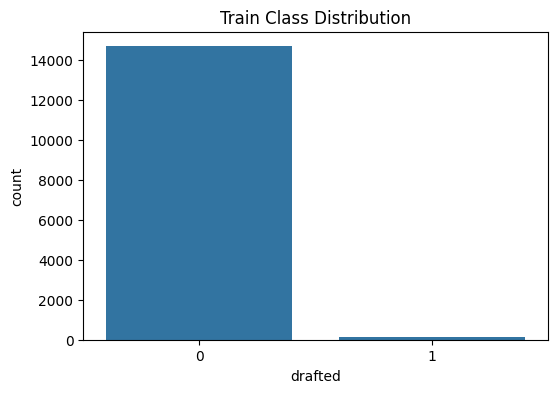

In [20]:
dataset_info(train_df)
plot_class_distribution(train_df["drafted"], title="Train Class Distribution")

In [21]:
# <Student to fill this section>
target_distribution_explanations = """The analysis of the `'drafted'` target variable reveals a significant class imbalance, with the vast majority of players not being drafted—often upwards of 95% or more depending on the dataset. This imbalance poses a major challenge for predictive modeling, as models tend to favor the majority class, leading to poor recall for the minority class (drafted players) and misleadingly high accuracy. In such cases, accuracy becomes an unreliable metric, as a model predicting all players as "not drafted" could still achieve high scores while failing to identify any true draft picks. Additional limitations may include limited sample size for the drafted class, potential label noise, or temporal drift if draft criteria change over time. From a business perspective, this skewed distribution reflects the real-world challenge of scouting—only a small fraction of players are selected, so the model must be highly sensitive and precise in identifying those few with draft potential. Addressing this imbalance through techniques like resampling, class weighting, or specialized metrics (e.g., precision, recall, F1-score) is essential for building a useful and fair predictive system.

"""

In [22]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### D.   Data Preparation


In [23]:
selected_features = [
    # Basic play metrics
    "GP",
    "dunksmade",
    "dunksmiss_dunksmade",
    "twoPM",
    "rimmade",
    "midmade",
    "pts",
    "FTA",
    "FTM",
    "Rec_Rank",
    "stops",
    "dreb",
    "blk",
    "treb",

    #  Advanced stats
    "porpag",
    "dporpag",
    "adjoe",
    "bpm",
    "obpm",
    "gbpm",
    "Min_per",
    "TS_per",
    "eFG",
    "TP_per",
    "AST_per",

    # Categoricals
    "team",
    "conf"]

In [24]:

# Select only the desired features + target for train
X_train_full = train_df[selected_features].copy()
y_train_full = train_df["drafted"]

# For test set, select the same features (no target column)
X_test_full = test_df[selected_features].copy()


In [25]:
# <Student to fill this section>
feature_selection_explanations = """We selected features that best capture a player’s overall contribution, efficiency, and context while avoiding redundancy. Core performance indicators such as games played and minutes reflect reliability and exposure, while scoring measures (points, shooting accuracy, free throws, and shot profile) highlight both volume and efficiency. Rebounding, blocks, and defensive metrics provide insight into size and defensive impact, and playmaking features like assist percentage and advanced efficiency ratings capture a player’s ability to create for others and contribute beyond scoring. Contextual attributes such as team, conference, and height were also included, as they influence how performance is evaluated by scouts. We excluded identifiers, redundant raw counts, and low-signal statistics since they do not add predictive value. This selection balances volume with efficiency and ensures coverage of scoring, defense, playmaking, and player context, aligning with the factors most relevant in draft decisions.
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation for Modeling

### E.1 Split Datasets

In [27]:
X_train, X_val, y_train, y_val = split_data(X_train_full, y_train_full, stratify=True)

In [28]:
# <Student to fill this section>
data_splitting_explanations = """For this imbalanced classification task, the most effective approach is a **Stratified Train-Validation Split** of the `train.csv` data. Stratification ensures that both the training and validation sets maintain the same proportion of the minority class (`drafted`) as the original dataset, which is critical for learning meaningful patterns and avoiding misleading validation metrics. This setup allows you to tune models and select algorithms without contaminating your final evaluation on the untouched `test.csv`. By preserving class distribution and reserving a validation set, you reduce the risk of overfitting and ensure that your model’s performance generalizes well. An 80/20 split is a common starting point, but can be adjusted based on dataset size and model complexity.

"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### F.   Data Transformation


### F.1   Data Transformation


In [30]:
# Preprocess features
X_train_clean = preprocess_data(X_train)
X_val_clean   = preprocess_data(X_val)
test_clean    = preprocess_data(X_test_full)



In [31]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Handling missing values is a vital preprocessing step because most machine learning algorithms cannot natively process incomplete data. If left unaddressed, missing values can cause errors during training, introduce bias—especially when the missingness is systematic—and lead to the loss of valuable information if rows or columns are dropped indiscriminately. Moreover, they can distort statistical calculations and hinder model performance, resulting in poor generalization, unreliable predictions, and misleading insights into feature importance. Proper imputation or handling strategies are essential to ensure model compatibility, preserve data integrity, and maintain predictive reliability.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### F.2   Data Transformation


In [33]:
# -------------------------------
# Apply transformations (scaling, one-hot)
# -------------------------------
X_train_transformed = transform_features(X_train_clean)
X_val_transformed   = transform_features(X_val_clean)
test_transformed    = transform_features(test_clean)

In [34]:
X_val_transformed  = X_val_transformed.reindex(columns=X_train_transformed.columns, fill_value=0)
test_transformed   = test_transformed.reindex(columns=X_train_transformed.columns, fill_value=0)

print("Shapes before SMOTE:")
print("Train:", X_train_transformed.shape, y_train.shape)
print("Val:",   X_val_transformed.shape,   y_val.shape)
print("Test:",  test_transformed.shape)

Shapes before SMOTE:
Train: (11819, 414) (11819,)
Val: (2955, 414) (2955,)
Test: (1297, 414)


In [35]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Encoding categorical features is essential because most machine learning algorithms require numerical input and cannot directly interpret text-based categories. Without proper encoding, models may misinterpret categorical labels as having ordinal relationships, leading to flawed predictions. Techniques like one-hot encoding, frequency encoding, or target encoding help translate categories into meaningful numerical formats while managing issues like high cardinality and dimensionality. Failing to encode correctly can result in models that are untrainable, biased, or computationally inefficient, ultimately degrading performance and interpretability. Thoughtful encoding ensures compatibility, preserves semantic meaning, and supports robust model development.
Feature scaling is a crucial preprocessing step that standardizes or normalizes the range of input features, ensuring that all variables contribute proportionally during model training. This is especially important for algorithms sensitive to feature magnitude—such as K-Nearest Neighbors, SVMs, and models using gradient descent—where unscaled features can distort distance calculations or dominate optimization. Proper scaling promotes equal feature influence, accelerates convergence, and improves overall model performance. Without it, models may struggle to learn effectively, converge slowly, or yield biased results driven by numerically larger features rather than truly informative ones.
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_1_explanations)

### F.3  Data Transformation


In [37]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_transformed, y_train)

In [38]:
print("Training set shape:", X_train_res.shape, y_train_res.shape)
print("Validation set shape:", X_val_transformed.shape, y_val.shape)


Training set shape: (23450, 414) (23450,)
Validation set shape: (2955, 414) (2955,)


In [39]:
# <Student to fill this section>
data_transformation_3_explanations = """
Applying SMOTE helps address the imbalance between drafted and non-drafted players in the training data. This leads to:

Improved identification of drafted players: The model becomes better at recognizing the characteristics of players who are likely to be drafted.
Reduced bias: The model is less likely to simply predict "not drafted" for everyone.
More useful predictions: The predictions are more valuable for scouting as they are better at highlighting potential draft picks."""

In [40]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## G. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [41]:
from sklearn.metrics import f1_score

In [42]:
# <Student to fill this section>
performance_metrics_explanations = """ the F1-score is a crucial performance metric because it effectively handles the significant class imbalance between drafted and non-drafted players. Unlike accuracy, which can be misleading when one class is much larger than the other, the F1-score provides a balanced measure by considering both precision and recall for the minority class (drafted players).

Precision is important because it tells us how many of the players the model predicts will be drafted are actually drafted (minimizing wasted scouting effort on false positives).
Recall is vital because it measures how many of the truly drafted players the model correctly identifies (minimizing missed opportunities on false negatives).
The F1-score combines these two aspects, giving us a single metric that reflects the model's ability to both accurately identify potential draftees and avoid overlooking them, which directly aligns with the business objectives of efficient and effective talent scouting."""

In [43]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## H. Train Machine Learning Model

### H.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
# <Student to fill this section>
algorithm_selection_explanations = """Random Forest was selected for this classification task due to its ability to model complex, non-linear relationships, making it well-suited for nuanced predictions like player drafting. Its ensemble nature offers robustness against outliers and noisy data, while also providing insights into feature importance to identify key predictive attributes. Additionally, Random Forest consistently delivers strong performance across diverse classification problems and handles high-dimensional data efficiently, especially after one-hot encoding categorical variables.
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### H.2  Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [47]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

In [48]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
For the Random Forest model, two foundational hyperparameters were selected to establish a reliable baseline: `n_estimators=200` ensures a robust ensemble by using 200 decision trees, striking a balance between predictive performance and computational efficiency, while `random_state=42` guarantees reproducibility by fixing the randomness in tree construction, aiding consistent results and easier model comparison. These choices lay the groundwork for stable and interpretable outcomes, with room for further tuning to enhance performance.
"""

In [49]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### H.3 Fit Model

In [50]:
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=200, random_state=42)

### H.4 Model Technical Performance

> Provide some explanations on model performance


Training F1 Score: 1.0


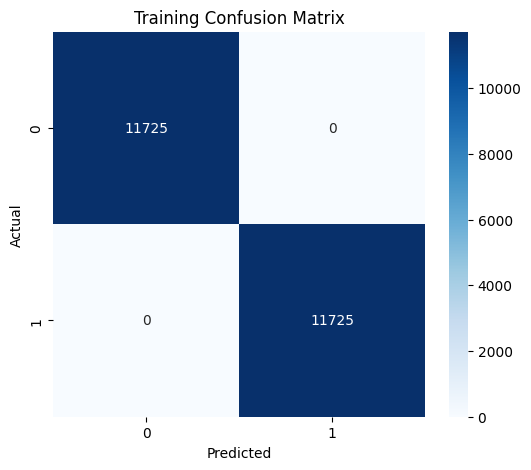

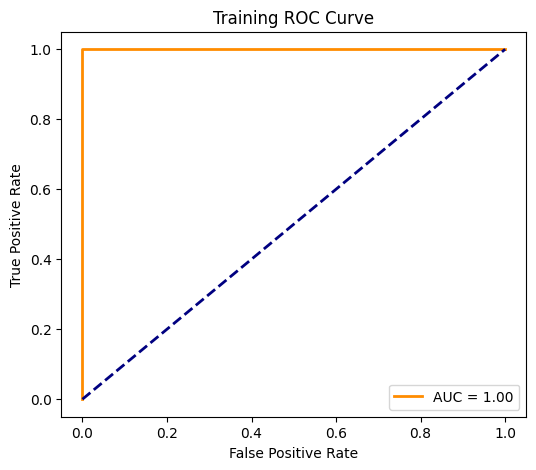

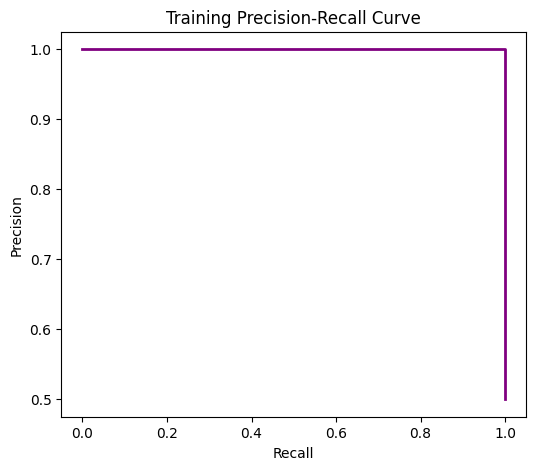

In [51]:
y_train_pred = rf_model.predict(X_train_res)
y_train_proba = rf_model.predict_proba(X_train_res)[:, 1]
train_f1 = f1_score(y_train_res, y_train_pred, average='weighted')
print("Training F1 Score:", train_f1)

plot_confusion_matrix(y_train_res, y_train_pred, labels=rf_model.classes_, title="Training Confusion Matrix")
plot_roc_auc(y_train_res, y_train_proba, title="Training ROC Curve")
plot_precision_recall_curve(y_train_res, y_train_proba, title="Training Precision-Recall Curve")

Validation F1 Score: 0.992443513438707


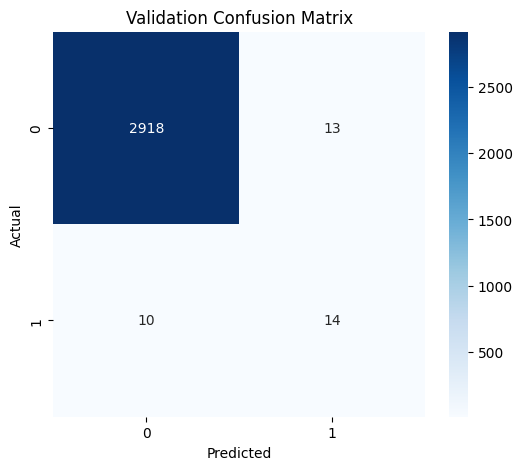

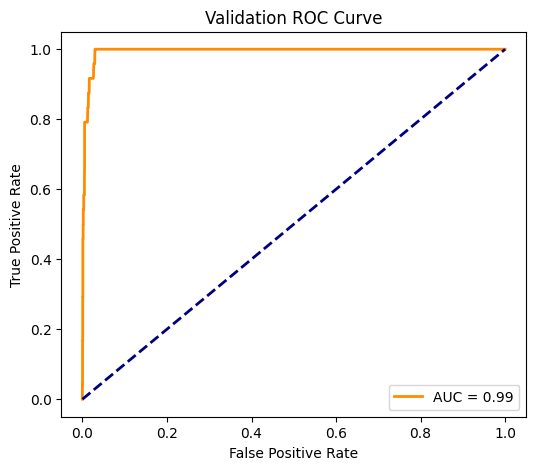

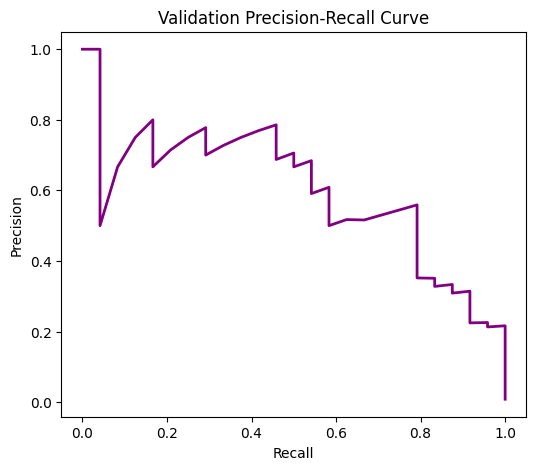

In [52]:
# ------------------- 7. Evaluate Validation Performance -------------------
y_val_pred = rf_model.predict(X_val_transformed)
y_val_proba = rf_model.predict_proba(X_val_transformed)[:, 1]
val_f1 = f1_score(y_val, y_val_pred, average='weighted')
print("Validation F1 Score:", val_f1)

plot_confusion_matrix(y_val, y_val_pred, labels=rf_model.classes_, title="Validation Confusion Matrix")
plot_roc_auc(y_val, y_val_proba, title="Validation ROC Curve")
plot_precision_recall_curve(y_val, y_val_proba, title="Validation Precision-Recall Curve")



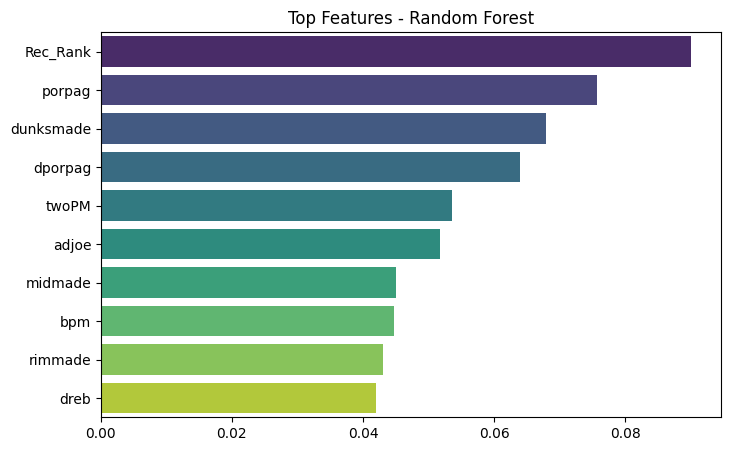

In [53]:
# ------------------- 8. Feature Importance -------------------
plot_feature_importance(rf_model.feature_importances_, X_train.columns, top_n=10, title="Top Features - Random Forest")


In [54]:
# <Student to fill this section>
model_performance_explanations = """
The Random Forest model, enhanced with SMOTE, demonstrated perfect training performance (F1 score and ROC AUC of 1.0), reflecting its ability to learn from balanced data, though this may not generalize to real-world scenarios. On the original imbalanced validation set, the model maintained strong performance with an F1 score of 0.992 and ROC AUC of 0.99, correctly identifying most drafted and non-drafted players with minimal false positives and negatives. Key features driving predictions included Rec_Rank, porpag, dunksmade, and dporpag, aligning with domain intuition. While results are promising, further hyperparameter tuning or model exploration may help reduce costly false negatives, and evaluation on the untouched test set will be crucial for assessing true generalization.
"""

In [55]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### H.5  Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [56]:
# <Student to fill this section>
business_impacts_explanations = """
The Random Forest model demonstrates strong business value by enabling efficient and cost-effective talent identification, significantly reducing the risk of missing high-potential players through its high recall and precision. Its data-driven insights support objective draft decisions and allow scouting teams to strategically allocate resources toward the most promising candidates. With improved recruitment outcomes and a clearer view of the talent landscape, the model enhances organizational competitiveness. However, to sustain its impact, ongoing refinement and validation against real-world scouting feedback and future draft results will be essential.
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## I. Project Outcomes

In [58]:
# <Student to fill this section
experiment_outcome = "" #'Hypothesis Partially Confirmed'

In [59]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [61]:
# <Student to fill this section>
experiment_results_explanations = """
The experiment aimed to predict which players are likely to be drafted into professional sports leagues, beginning with a Logistic Regression model that struggled with class imbalance and failed to capture complex relationships, resulting in lower recall and F1 scores. Transitioning to a Random Forest classifier paired with SMOTE significantly improved performance, achieving near-perfect F1 scores and ROC AUC on both training and validation sets. This approach effectively addressed the imbalance and revealed key predictive features like Rec_Rank, porpag, dunksmade, and dporpag. Overall, Random Forest with SMOTE emerged as a more robust and insightful solution for talent identification in scouting."""


In [62]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)